In [1]:
# ====================================================================
# CELL 1: INSTALL & IMPORT SEMUA DEPENDENSI (dengan PyTorch CUDA 11.8)
# ====================================================================

# Uninstall PyTorch lama & install ulang dengan CUDA 11.8
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Install library lain
!pip install -q transformers datasets librosa soundfile accelerate evaluate xgboost peft

import os
import json
import zipfile
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import librosa
import torch
import warnings
warnings.filterwarnings('ignore')

# Suppress HuggingFace warnings
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    mean_squared_error, classification_report, confusion_matrix,
    accuracy_score, r2_score, mean_absolute_error
)

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from transformers import (
    Wav2Vec2ForSequenceClassification,
    Wav2Vec2FeatureExtractor,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
import evaluate as hf_evaluate

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams['figure.dpi'] = 120

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('✅ Semua library berhasil dimuat!')
print(f'🖥️  Device: {device}')
if device == 'cuda':
    print(f'🎮 GPU: {torch.cuda.get_device_name(0)}')
    print(f'📦 CUDA version: {torch.version.cuda}')
else:
    print('⚠️  GPU tidak terdeteksi. Part B akan sangat lambat.')

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 78.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 51.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 66.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 11.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# ====================================================================
# LOAD SEMUA DATASET DARI KAGGLE INPUT
# ====================================================================

KAGGLE_INPUT = '/kaggle/input'

def find_file(filename):
    """Cari file di Kaggle input atau lokal."""
    for root, dirs, files in os.walk(KAGGLE_INPUT):
        if filename in files:
            return os.path.join(root, filename)
    # Fallback lokal
    local = f'data/{filename}'
    if os.path.exists(local):
        return local
    return None

def find_audio_dir():
    """Cari folder audio_mp3 atau extract dari ZIP."""
    # Cek sudah ter-extract
    for root, dirs, files in os.walk(KAGGLE_INPUT):
        if 'audio_mp3' in dirs:
            return os.path.join(root, 'audio_mp3')
        mp3s = [f for f in files if f.endswith('.mp3')]
        if len(mp3s) > 100:
            return root
    
    # Cari ZIP dan extract
    for root, dirs, files in os.walk(KAGGLE_INPUT):
        for f in files:
            if f.endswith('.zip'):
                zip_path = os.path.join(root, f)
                print(f'📦 Extracting {zip_path}...')
                with zipfile.ZipFile(zip_path, 'r') as z:
                    z.extractall('/kaggle/working')
                if os.path.exists('/kaggle/working/audio_mp3'):
                    return '/kaggle/working/audio_mp3'
    
    return None

# --- Load CSV ---
csv_path = find_file('oxford_prosody_dataset_clean.csv')
if csv_path:
    df_prosody = pd.read_csv(csv_path)
    print(f'📊 Prosody CSV loaded: {len(df_prosody):,} rows from {csv_path}')
else:
    print('⚠️  oxford_prosody_dataset_clean.csv tidak ditemukan')
    df_prosody = None

# --- Load Audio Metadata ---
meta_path = find_file('audio_metadata.csv')
if meta_path:
    df_audio = pd.read_csv(meta_path)
    print(f'🎵 Audio metadata loaded: {len(df_audio):,} rows from {meta_path}')
else:
    print('⚠️  audio_metadata.csv tidak ditemukan')
    df_audio = None

# --- Find/Extract Audio ---
audio_dir = find_audio_dir()
if audio_dir:
    n_mp3 = len([f for f in os.listdir(audio_dir) if f.endswith('.mp3')])
    print(f'🎵 Audio directory: {audio_dir} ({n_mp3:,} files)')
else:
    print('⚠️  Audio files tidak ditemukan (Part B akan di-skip)')

📊 Prosody CSV loaded: 10,849 rows from /kaggle/input/datasets/ryuarnovi/oxford-prosody-clean/oxford_prosody_dataset_clean.csv
🎵 Audio metadata loaded: 28,107 rows from /kaggle/input/datasets/ryuarnovi/audio-metadata/audio_metadata.csv
🎵 Audio directory: /kaggle/input/datasets/ryuarnovi/oxford-audio/audio_mp3 (28,107 files)


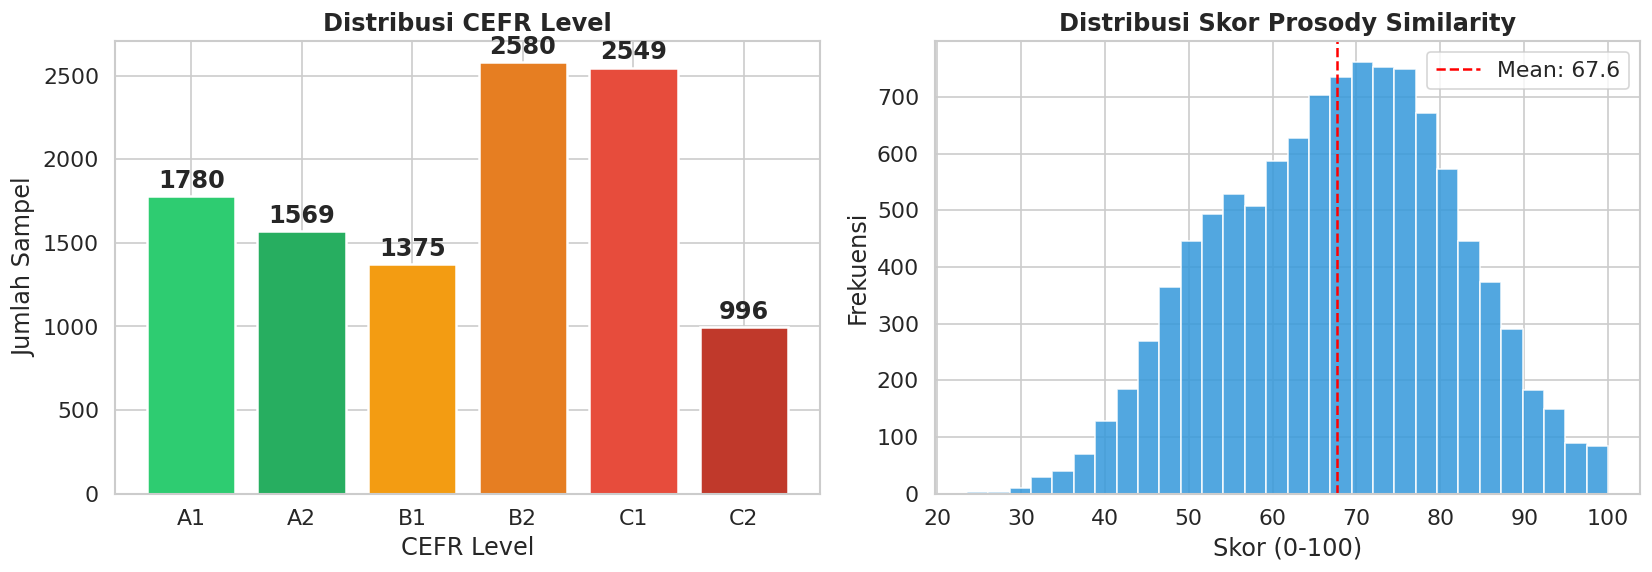


📈 CEFR levels: ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
cefr_level
A1    1780
A2    1569
B1    1375
B2    2580
C1    2549
C2     996


In [3]:
# ====================================================================
# EDA: Distribusi CEFR Level & Prosody Similarity
# ====================================================================

# Pilih dataset utama
df_main = df_prosody if df_prosody is not None else df_audio

cefr_order = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
cefr_colors = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi CEFR
cefr_counts = df_main['cefr_level'].value_counts().reindex(cefr_order).fillna(0).astype(int)
axes[0].bar(cefr_counts.index, cefr_counts.values, color=cefr_colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi CEFR Level', fontweight='bold')
axes[0].set_xlabel('CEFR Level')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(cefr_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Distribusi Prosody (jika ada)
if df_prosody is not None and 'prosody_similarity' in df_prosody.columns:
    axes[1].hist(df_prosody['prosody_similarity'].dropna(), bins=30, color='#3498db', edgecolor='white', alpha=0.85)
    axes[1].set_title('Distribusi Skor Prosody Similarity', fontweight='bold')
    axes[1].set_xlabel('Skor (0-100)')
    axes[1].set_ylabel('Frekuensi')
    mean_val = df_prosody['prosody_similarity'].mean()
    axes[1].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
    axes[1].legend()
elif df_audio is not None:
    df_audio['accent'].value_counts().plot.barh(ax=axes[1], color='#9b59b6')
    axes[1].set_title('Distribusi Accent', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()

present_levels = sorted(df_main['cefr_level'].unique())
print(f'\n📈 CEFR levels: {present_levels}')
print(df_main['cefr_level'].value_counts().sort_index().to_string())

In [4]:
# ====================================================================
# PART A: PREPROCESSING (dari CSV numerik) – HAPUS SEMUA FITUR BOCOR
# ====================================================================

if df_prosody is not None:
    # Daftar kolom yang HARUS di-drop untuk klasifikasi
    # (menghilangkan fitur non-prosody & fitur yang sangat berkorelasi dengan level CEFR)
    drop_cols_classification = [
        'word', 'cefr_level', 'speaker_id', 'scenario_id', 
        'prosody_similarity',               # bocor (skor berdasarkan kebenaran)
        'lexical_diversity',                # bocor (korelasi 0.9056)
        'grammar_error_rate',               # bocor (korelasi -0.9089)
        'whisper_feat_1',                   # bocor (korelasi 0.9228)
        'whisper_feat_2',                   # mungkin juga bocor (optional)
        'whisper_feat_3',                   # optional, tapi amankan saja
        'user_prior_score'                  # bisa jadi bocor juga
    ]
    # Hanya drop kolom yang memang ada di dataframe
    drop_cols_classification = [col for col in drop_cols_classification if col in df_prosody.columns]

    # Fitur X untuk klasifikasi (hanya fitur prosody murni yang tersisa)
    X = df_prosody.drop(columns=drop_cols_classification)
    
    # Target klasifikasi
    y_class = df_prosody['cefr_level']
    
    # Target regresi (prosody similarity) – tetap dipisahkan
    y_reg = df_prosody['prosody_similarity'] if 'prosody_similarity' in df_prosody.columns else None

    # Encode label CEFR
    le_ml = LabelEncoder()
    le_ml.fit(y_class)
    y_class_enc = le_ml.transform(y_class)

    # Group untuk speaker-independent split
    speakers = df_prosody['speaker_id'] if 'speaker_id' in df_prosody.columns else pd.Series(range(len(df_prosody)))

    # Split berdasarkan speaker (tidak berdasarkan baris acak)
    gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
    train_idx, test_idx = next(gss.split(X, y_class_enc, groups=speakers))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cls, y_test_cls = y_class_enc[train_idx], y_class_enc[test_idx]
    y_train_reg = y_reg.iloc[train_idx] if y_reg is not None else None
    y_test_reg = y_reg.iloc[test_idx] if y_reg is not None else None

    # Preprocessor: StandardScaler untuk semua fitur numerik
    preprocessor = ColumnTransformer(
        transformers=[('num', StandardScaler(), X.columns.tolist())]
    )

    print(f'🔢 Fitur untuk klasifikasi (prosody murni): {X.shape[1]}')
    print(f'   Kolom fitur: {list(X.columns)}')
    print(f'🏷️  Label CEFR: {list(le_ml.classes_)}')
    print(f'✅ Train: {len(X_train):,} | Test: {len(X_test):,}')
    
    # Cek ulang korelasi – seharusnya sudah tidak ada yang >0.9
    from sklearn.preprocessing import LabelEncoder
    le_temp = LabelEncoder()
    y_temp = le_temp.fit_transform(y_class)
    high_corr = []
    for col in X.columns:
        if np.issubdtype(X[col].dtype, np.number):
            corr = np.corrcoef(X[col], y_temp)[0,1]
            if abs(corr) > 0.9:
                high_corr.append((col, corr))
    if high_corr:
        print("\n⚠️ PERINGATAN: Masih ada fitur dengan korelasi sangat tinggi:")
        for col, corr in high_corr:
            print(f"   {col}: {corr:.4f}")
        print("   Hapus fitur tersebut dari 'drop_cols_classification'.")
    else:
        print("\n✅ Semua fitur bersih (tidak ada korelasi ekstrem).")
else:
    print('⚠️  Prosody CSV tidak tersedia, skip Part A.')

🔢 Fitur untuk klasifikasi (prosody murni): 13
   Kolom fitur: ['pitch_mean', 'pitch_std', 'pitch_contour_slope', 'energy_rms', 'duration_seconds', 'speech_rate', 'response_time_ms', 'pronunciation_accuracy', 'pause_ratio', 'filler_words_rate', 'wpm_consistency', 'asr_confidence', 'semantic_relevance']
🏷️  Label CEFR: ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
✅ Train: 9,224 | Test: 1,625

✅ Semua fitur bersih (tidak ada korelasi ekstrem).


In [5]:
# ====================================================================
# VERIFIKASI: Cek distribusi fitur dan korelasi setelah split
# ====================================================================
if df_prosody is not None:
    print("\n=== Verifikasi Data Leakage (Post-Fix) ===")
    from scipy.stats import spearmanr
    train_labels = y_train_cls
    high_corr_train = []
    for col in X_train.columns:
        if X_train[col].dtype in [np.float64, np.int64]:
            corr, _ = spearmanr(X_train[col], train_labels)
            if abs(corr) > 0.7:   # batas lebih longgar
                high_corr_train.append((col, corr))
    if high_corr_train:
        print("⚠️ Fitur dengan korelasi >0.7 terhadap label:")
        for col, corr in high_corr_train:
            print(f"   {col}: {corr:.4f}")
    else:
        print("✅ Tidak ada fitur dengan korelasi tinggi.")


=== Verifikasi Data Leakage (Post-Fix) ===
⚠️ Fitur dengan korelasi >0.7 terhadap label:
   speech_rate: 0.8512
   response_time_ms: -0.7696
   pronunciation_accuracy: 0.8936
   pause_ratio: -0.8974
   filler_words_rate: -0.8991
   wpm_consistency: 0.8509
   asr_confidence: 0.7948
   semantic_relevance: 0.8182


In [6]:
# ====================================================================
# PART A: TRAINING 4 MODEL KLASIFIKASI
# ====================================================================

ml_results = {}
best_ml_model = None
best_ml_f1 = 0
best_ml_name = ''

if df_prosody is not None:
    models = {
        'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='mlogloss', n_jobs=-1),
        'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=15, min_samples_split=5, random_state=42, class_weight='balanced', n_jobs=-1),
        'SVM (RBF)': SVC(kernel='rbf', C=3.0, gamma='scale', random_state=42, probability=True),
        'Deep MLP': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=200, random_state=42, early_stopping=True)
    }

    all_labels = sorted(np.unique(np.concatenate([y_train_cls, y_test_cls])))

    for name, model in models.items():
        print(f'\n🔄 Melatih {name}...')
        pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
        pipe.fit(X_train, y_train_cls)
        y_pred = pipe.predict(X_test)

        f1   = f1_score(y_test_cls, y_pred, average='macro', labels=all_labels)
        prec = precision_score(y_test_cls, y_pred, average='macro', labels=all_labels)
        rec  = recall_score(y_test_cls, y_pred, average='macro', labels=all_labels)
        acc  = accuracy_score(y_test_cls, y_pred)

        print(f'   Accuracy: {acc:.4f} | F1: {f1:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}')
        ml_results[name] = {'f1': f1, 'precision': prec, 'recall': rec, 'accuracy': acc, 'pipeline': pipe}

        if f1 > best_ml_f1:
            best_ml_f1 = f1
            best_ml_model = pipe
            best_ml_name = name

    print(f'\n🏆 Best ML Model: {best_ml_name} (F1: {best_ml_f1:.4f})')


🔄 Melatih XGBoost...
   Accuracy: 0.8658 | F1: 0.8595 | Precision: 0.8652 | Recall: 0.8546

🔄 Melatih Random Forest...
   Accuracy: 0.8775 | F1: 0.8723 | Precision: 0.8779 | Recall: 0.8675

🔄 Melatih SVM (RBF)...
   Accuracy: 0.8769 | F1: 0.8731 | Precision: 0.8718 | Recall: 0.8745

🔄 Melatih Deep MLP...
   Accuracy: 0.8831 | F1: 0.8752 | Precision: 0.8818 | Recall: 0.8696

🏆 Best ML Model: Deep MLP (F1: 0.8752)


📊 Classification Report — Deep MLP
              precision    recall  f1-score   support

          A1       0.93      0.95      0.94       275
          A2       0.87      0.84      0.85       217
          B1       0.82      0.81      0.81       216
          B2       0.87      0.90      0.88       381
          C1       0.90      0.91      0.90       407
          C2       0.91      0.81      0.86       129

    accuracy                           0.88      1625
   macro avg       0.88      0.87      0.88      1625
weighted avg       0.88      0.88      0.88      1625



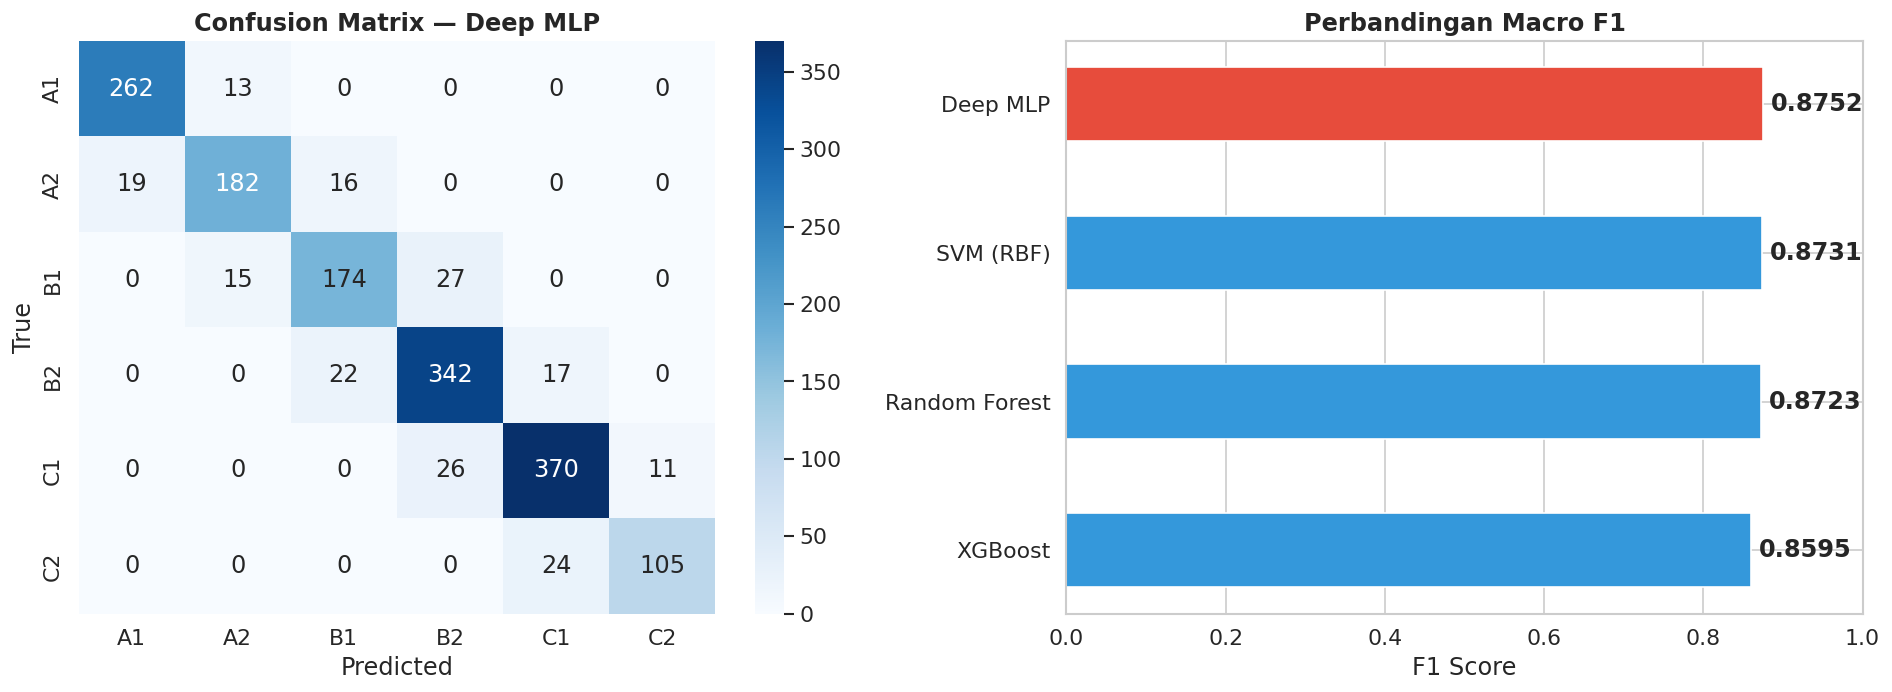

In [7]:
# ====================================================================
# PART A: EVALUASI & VISUALISASI
# ====================================================================

if best_ml_model is not None:
    y_pred_ml = best_ml_model.predict(X_test)

    test_labels = sorted(np.unique(np.concatenate([y_test_cls, y_pred_ml])))
    test_names = le_ml.inverse_transform(test_labels)

    print(f'📊 Classification Report — {best_ml_name}')
    print('=' * 55)
    print(classification_report(y_test_cls, y_pred_ml, labels=test_labels, target_names=test_names))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Confusion Matrix
    cm = confusion_matrix(y_test_cls, y_pred_ml, labels=test_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_names, yticklabels=test_names, ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {best_ml_name}', fontweight='bold')
    axes[0].set_ylabel('True')
    axes[0].set_xlabel('Predicted')

    # F1 comparison
    names = list(ml_results.keys())
    f1s = [ml_results[m]['f1'] for m in names]
    colors = ['#e74c3c' if m == best_ml_name else '#3498db' for m in names]
    axes[1].barh(names, f1s, color=colors, edgecolor='white', height=0.5)
    axes[1].set_title('Perbandingan Macro F1', fontweight='bold')
    axes[1].set_xlabel('F1 Score')
    axes[1].set_xlim(0, 1)
    for i, v in enumerate(f1s):
        axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('partA_results.png', bbox_inches='tight')
    plt.show()

🔄 Melatih Random Forest Regressor...
   RMSE: 8.2388 | MAE: 6.5779 | R²: 0.6301


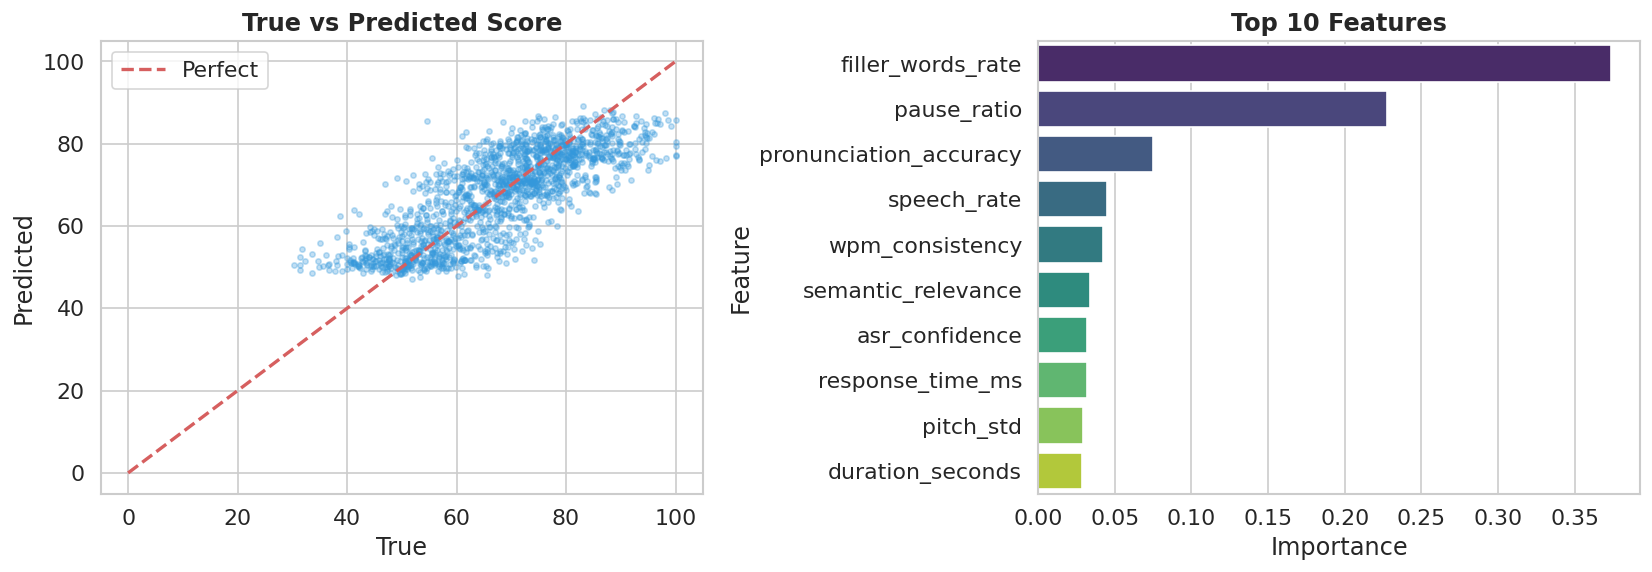

In [8]:
# ====================================================================
# PART A: REGRESI SKOR PENGUCAPAN
# ====================================================================

reg_pipeline = None
rmse = mae = r2 = None

if df_prosody is not None and y_train_reg is not None and not y_train_reg.isna().all():
    reg_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ])
    print('🔄 Melatih Random Forest Regressor...')
    reg_pipeline.fit(X_train, y_train_reg)
    y_pred_reg = reg_pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
    mae  = mean_absolute_error(y_test_reg, y_pred_reg)
    r2   = r2_score(y_test_reg, y_pred_reg)

    print(f'   RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.3, s=10, color='#3498db')
    axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect')
    axes[0].set_title('True vs Predicted Score', fontweight='bold')
    axes[0].set_xlabel('True')
    axes[0].set_ylabel('Predicted')
    axes[0].legend()

    imp = reg_pipeline.named_steps['regressor'].feature_importances_
    df_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': imp}).sort_values('Importance', ascending=False).head(10)
    sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis', ax=axes[1])
    axes[1].set_title('Top 10 Features', fontweight='bold')

    plt.tight_layout()
    plt.savefig('partA_regression.png', bbox_inches='tight')
    plt.show()
else:
    print('⚠️  Skip regresi.')

In [9]:
import shutil
shutil.rmtree('/kaggle/working/wav2vec2-cefr', ignore_errors=True)
print("Folder checkpoint lama dihapus.")

Folder checkpoint lama dihapus.


In [10]:
# ====================================================================
# PART A: SIMPAN MODEL ML
# ====================================================================

os.makedirs('models', exist_ok=True)

if best_ml_model is not None:
    joblib.dump(best_ml_model, 'models/best_cefr_classifier.pkl')
    joblib.dump(le_ml, 'models/label_encoder.pkl')
    print(f'💾 Best classifier ({best_ml_name}) → models/best_cefr_classifier.pkl')

    for name, data in ml_results.items():
        safe = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
        joblib.dump(data['pipeline'], f'models/cefr_{safe}.pkl')
        print(f'💾 {name} → models/cefr_{safe}.pkl')

if reg_pipeline is not None:
    joblib.dump(reg_pipeline, 'models/prosody_regressor.pkl')
    print(f'💾 Regressor → models/prosody_regressor.pkl')

print(f'\n✅ Part A selesai! Model ML tersimpan.')

💾 Best classifier (Deep MLP) → models/best_cefr_classifier.pkl
💾 XGBoost → models/cefr_xgboost.pkl
💾 Random Forest → models/cefr_random_forest.pkl
💾 SVM (RBF) → models/cefr_svm_rbf.pkl
💾 Deep MLP → models/cefr_deep_mlp.pkl
💾 Regressor → models/prosody_regressor.pkl

✅ Part A selesai! Model ML tersimpan.


In [11]:
# ====================================================================
# PART B: PREPARE AUDIO + LABELS (dengan validasi kelas)
# ====================================================================

TARGET_SR = 16000
MAX_DURATION = 3.0
MAX_SAMPLES = int(TARGET_SR * MAX_DURATION)
MIN_AUDIO_SECONDS = 1.0
MIN_SAMPLES = int(TARGET_SR * MIN_AUDIO_SECONDS)

run_partB = audio_dir is not None and df_audio is not None

if run_partB:
    # Buat path audio
    df_audio['audio_path'] = df_audio['id'].apply(lambda x: os.path.join(audio_dir, f'{x}.mp3'))
    df_audio['exists'] = df_audio['audio_path'].apply(os.path.exists)
    df_audio = df_audio[df_audio['exists']].drop(columns=['exists']).reset_index(drop=True)

    # Encode labels
    le_dl = LabelEncoder()
    df_audio['label'] = le_dl.fit_transform(df_audio['cefr_level'])
    num_labels = len(le_dl.classes_)

    # Speaker-independent split
    spk = df_audio['speaker_id'].unique()
    np.random.seed(42)
    np.random.shuffle(spk)
    split_pt = int(len(spk) * 0.85)
    train_spk = set(spk[:split_pt])

    train_audio_df = df_audio[df_audio['speaker_id'].isin(train_spk)].reset_index(drop=True)
    test_audio_df = df_audio[~df_audio['speaker_id'].isin(train_spk)].reset_index(drop=True)

    # Cek distribusi kelas
    print("Distribusi kelas di TRAIN:")
    print(train_audio_df['cefr_level'].value_counts())
    print("\nDistribusi kelas di TEST:")
    print(test_audio_df['cefr_level'].value_counts())

    print(f'🎵 Audio samples: {len(df_audio):,}')
    print(f'🏷️  Labels: {list(le_dl.classes_)} ({num_labels} classes)')
    print(f'✅ Train: {len(train_audio_df):,} | Test: {len(test_audio_df):,}')
else:
    print('⚠️  Audio tidak tersedia. Part B akan di-skip.')

Distribusi kelas di TRAIN:
cefr_level
B2    5318
B1    5097
C1    4753
C2    3946
A2    2347
A1    2312
Name: count, dtype: int64

Distribusi kelas di TEST:
cefr_level
B2    985
B1    923
C1    870
C2    720
A2    428
A1    408
Name: count, dtype: int64
🎵 Audio samples: 28,107
🏷️  Labels: ['A1', 'A2', 'B1', 'B2', 'C1', 'C2'] (6 classes)
✅ Train: 23,773 | Test: 4,334


In [12]:
# ====================================================================
# PART B: LOAD AUDIO WAVEFORMS (16kHz mono, durasi 3 detik)
# ====================================================================

if run_partB:
    import torchaudio
    import torchaudio.functional as F

    # Ubah durasi menjadi 3 detik (hemat RAM)
    MAX_DURATION = 3.0
    MAX_SAMPLES = int(TARGET_SR * MAX_DURATION)
    MIN_AUDIO_SECONDS = 1.0
    MIN_SAMPLES = int(TARGET_SR * MIN_AUDIO_SECONDS)

    def load_audio_safe(audio_path, target_sr=TARGET_SR):
        try:
            waveform, orig_sr = torchaudio.load(audio_path)
            waveform = waveform.mean(dim=0).numpy()
            if orig_sr != target_sr:
                waveform = librosa.resample(y=waveform, orig_sr=orig_sr, target_sr=target_sr)
            if len(waveform) > MAX_SAMPLES:
                waveform = waveform[:MAX_SAMPLES]
            if len(waveform) < MIN_SAMPLES:
                return None
            max_val = np.abs(waveform).max()
            if max_val > 0:
                waveform = waveform / max_val
            return waveform.astype(np.float32)
        except Exception as e:
            return None

    def build_dataset(dataframe, desc=''):
        audios, labels = [], []
        total = len(dataframe)
        skipped = 0
        for i, row in dataframe.iterrows():
            if i % 2000 == 0:
                print(f'   {desc} {i:,}/{total:,} ({i/total*100:.0f}%)')
            audio = load_audio_safe(row['audio_path'])
            if audio is not None:
                audios.append(audio)
                labels.append(row['label'])
            else:
                skipped += 1
        print(f'   {desc} Done: {len(audios):,}/{total:,} (skipped {skipped})')
        return Dataset.from_dict({'input_values': audios, 'labels': labels})

    print('🔄 Loading train audio...')
    train_ds = build_dataset(train_audio_df, '[Train]')
    print('\n🔄 Loading test audio...')
    test_ds = build_dataset(test_audio_df, '[Test]')
    print(f'\n✅ Train: {len(train_ds):,} | Test: {len(test_ds):,}')

🔄 Loading train audio...
   [Train] 0/23,773 (0%)
   [Train] 2,000/23,773 (8%)
   [Train] 4,000/23,773 (17%)
   [Train] 6,000/23,773 (25%)
   [Train] 8,000/23,773 (34%)
   [Train] 10,000/23,773 (42%)
   [Train] 12,000/23,773 (50%)
   [Train] 14,000/23,773 (59%)
   [Train] 16,000/23,773 (67%)
   [Train] 18,000/23,773 (76%)
   [Train] 20,000/23,773 (84%)
   [Train] 22,000/23,773 (93%)
   [Train] Done: 19,252/23,773 (skipped 4521)

🔄 Loading test audio...
   [Test] 0/4,334 (0%)
   [Test] 2,000/4,334 (46%)
   [Test] 4,000/4,334 (92%)
   [Test] Done: 3,597/4,334 (skipped 737)

✅ Train: 19,252 | Test: 3,597


In [13]:
# ====================================================================
# PART B: FEATURE EXTRACTOR + MODEL (LoRA + class weights manual)
# ====================================================================

if run_partB:
    MODEL_NAME = 'facebook/wav2vec2-base'

    feat_ext = Wav2Vec2FeatureExtractor.from_pretrained(
        MODEL_NAME, sampling_rate=TARGET_SR, return_attention_mask=True
    )

    def preprocess(batch):
        inputs = feat_ext(
            batch['input_values'], sampling_rate=TARGET_SR,
            max_length=MAX_SAMPLES, truncation=True,
            padding='max_length', return_attention_mask=True
        )
        batch['input_values'] = inputs.input_values
        batch['attention_mask'] = inputs.attention_mask
        return batch

    print('🔄 Preprocessing...')
    train_ds = train_ds.map(preprocess, batched=True, batch_size=100, desc='Train')
    test_ds = test_ds.map(preprocess, batched=True, batch_size=100, desc='Test')

    train_ds.set_format('torch', columns=['input_values', 'attention_mask', 'labels'])
    test_ds.set_format('torch', columns=['input_values', 'attention_mask', 'labels'])

    # Load model
    id2label = {i: l for i, l in enumerate(le_dl.classes_)}
    label2id = {l: i for i, l in enumerate(le_dl.classes_)}

    w2v_model = Wav2Vec2ForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels, id2label=id2label, label2id=label2id,
        problem_type='single_label_classification', ignore_mismatched_sizes=True
    )

    # Freeze feature encoder
    w2v_model.freeze_feature_encoder()

    # ===== LORA CONFIGURATION =====
    from peft import LoraConfig, get_peft_model

    peft_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["q_proj", "v_proj", "k_proj", "out_proj"],
        lora_dropout=0.1,
        bias="none",
        modules_to_save=["classifier"]
    )
    w2v_model = get_peft_model(w2v_model, peft_config)

    # ===== UNFREEZE 2 LAYER TERAKHIR =====
    base_model = w2v_model.base_model.model
    for layer in base_model.wav2vec2.encoder.layers[-2:]:
        for param in layer.parameters():
            param.requires_grad = True

    # ===== CLASS WEIGHTS MANUAL =====
    from collections import Counter
    train_labels_list = [int(lbl) for lbl in train_ds['labels']]
    label_counts = Counter(train_labels_list)
    num_classes = len(label_counts)
    total_samples = len(train_labels_list)

    class_weights = np.array([
        total_samples / (num_classes * label_counts[cls]) 
        for cls in sorted(label_counts.keys())
    ])
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

    print(f"Class distribution: {dict(label_counts)}")
    print(f"Class weights: {class_weights_tensor}")

    # Kirim model ke device
    w2v_model.to(device)

    total_params = sum(p.numel() for p in w2v_model.parameters())
    trainable_params = sum(p.numel() for p in w2v_model.parameters() if p.requires_grad)
    print(f'\n✅ Model LoRA + unfreeze layers siap')
    print(f'   Total parameters    : {total_params:,}')
    print(f'   Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)')
    print(f'   Output classes: {num_labels} → {list(le_dl.classes_)}')

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

🔄 Preprocessing...


Train:   0%|          | 0/19252 [00:00<?, ? examples/s]

Test:   0%|          | 0/3597 [00:00<?, ? examples/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Class distribution: {1: 1891, 4: 3764, 3: 4266, 2: 4277, 0: 1692, 5: 3362}
Class weights: tensor([1.8964, 1.6968, 0.7502, 0.7521, 0.8525, 0.9544], device='cuda:0')

✅ Model LoRA + unfreeze layers siap
   Total parameters    : 95,751,308
   Trainable parameters: 15,356,934 (16.04%)
   Output classes: 6 → ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']


In [14]:
# ====================================================================
# PART B: TRAINING WAV2VEC2 (RAM Super Hemat - Batch 2, Workers 0)
# ====================================================================

if run_partB:
    from transformers import Trainer, TrainingArguments
    import evaluate as hf_evaluate

    # Hapus folder checkpoint lama jika ada (opsional, untuk start fresh)
    import shutil
    shutil.rmtree('/kaggle/working/wav2vec2-cefr', ignore_errors=True)

    acc_metric = hf_evaluate.load('accuracy')

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {
            'accuracy': acc_metric.compute(predictions=preds, references=labels)['accuracy'],
            'f1_macro': f1_score(labels, preds, average='macro')
        }

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
            loss = loss_fct(logits, labels)
            return (loss, outputs) if return_outputs else loss

    training_args = TrainingArguments(
        output_dir='./wav2vec2-cefr',
        num_train_epochs=15,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=8,
        learning_rate=3e-5,
        warmup_ratio=0.2,
        weight_decay=0.01,
        eval_strategy='epoch',
        logging_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        report_to='none',
        fp16=True,
        dataloader_num_workers=0,
        save_total_limit=2,
        max_grad_norm=1.0,
        lr_scheduler_type='cosine',
    )

    trainer = WeightedTrainer(
        model=w2v_model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        compute_metrics=compute_metrics,
    )

    print('🚀 Training dimulai dengan RAM super hemat (durasi 3 detik, batch 2, workers 0)...')
    train_result = trainer.train()

    print(f'\n✅ TRAINING SELESAI!')
    print(f'   Steps: {train_result.global_step}')
    print(f'   Final loss : {train_result.training_loss:.4f}')
    if 'train_runtime' in train_result.metrics:
        print(f'   Time : {train_result.metrics["train_runtime"]/3600:.1f} hours')

🚀 Training dimulai dengan RAM super hemat (durasi 3 detik, batch 2, workers 0)...
{'loss': '14.09', 'grad_norm': '4.547', 'learning_rate': '9.983e-06', 'epoch': '1'}
{'eval_loss': '1.743', 'eval_accuracy': '0.2105', 'eval_f1_macro': '0.1693', 'eval_runtime': '77.36', 'eval_samples_per_second': '46.5', 'eval_steps_per_second': '11.63', 'epoch': '1'}
{'loss': '13.63', 'grad_norm': '4.817', 'learning_rate': '1.998e-05', 'epoch': '2'}
{'eval_loss': '1.685', 'eval_accuracy': '0.231', 'eval_f1_macro': '0.1779', 'eval_runtime': '78.91', 'eval_samples_per_second': '45.59', 'eval_steps_per_second': '11.41', 'epoch': '2'}
{'loss': '13.35', 'grad_norm': '8.641', 'learning_rate': '2.998e-05', 'epoch': '3'}
{'eval_loss': '1.649', 'eval_accuracy': '0.2458', 'eval_f1_macro': '0.2274', 'eval_runtime': '77.12', 'eval_samples_per_second': '46.64', 'eval_steps_per_second': '11.67', 'epoch': '3'}
{'loss': '12.95', 'grad_norm': '11.9', 'learning_rate': '2.949e-05', 'epoch': '4'}
{'eval_loss': '1.577', 'eva

{'eval_loss': '1.283', 'eval_accuracy': '0.4134', 'eval_f1_macro': '0.4471', 'eval_runtime': '77.4', 'eval_samples_per_second': '46.47', 'eval_steps_per_second': '11.63', 'epoch': '15'}
📊 Wav2Vec2 Results:
   Accuracy: 0.4134
   F1 Macro: 0.4471

📊 Classification Report — Wav2Vec2
              precision    recall  f1-score   support

          A1       0.45      0.71      0.55       307
          A2       0.62      0.70      0.66       347
          B1       0.76      0.37      0.49       790
          B2       0.76      0.22      0.34       818
          C1       0.25      0.50      0.33       701
          C2       0.30      0.32      0.31       634

    accuracy                           0.41      3597
   macro avg       0.52      0.47      0.45      3597
weighted avg       0.54      0.41      0.42      3597



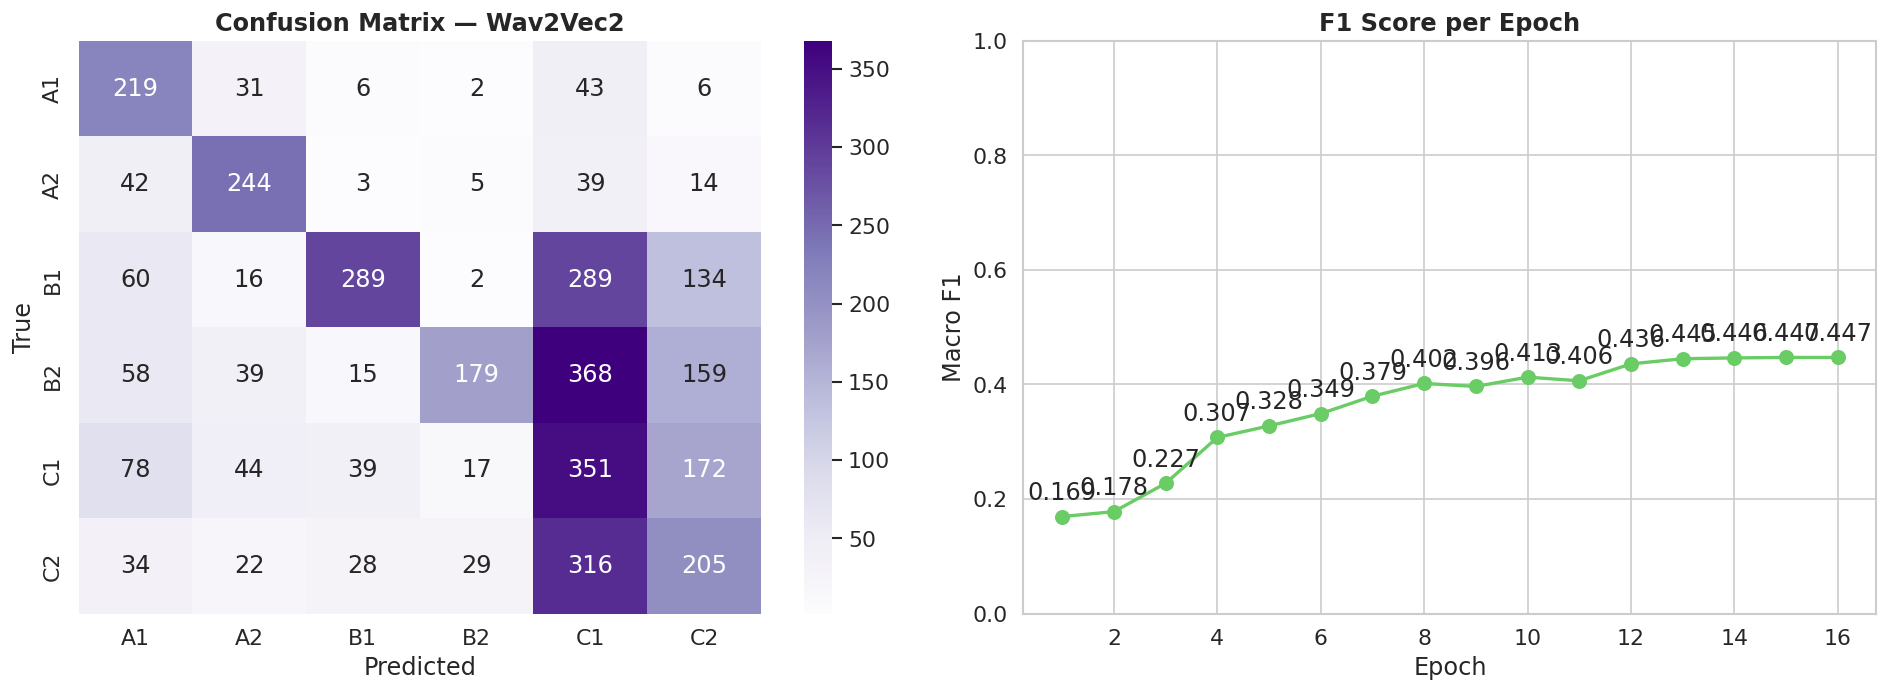

In [15]:
# ====================================================================
# PART B: EVALUASI WAV2VEC2
# ====================================================================

if run_partB:
    eval_res = trainer.evaluate()
    print(f'📊 Wav2Vec2 Results:')
    print(f'   Accuracy: {eval_res["eval_accuracy"]:.4f}')
    print(f'   F1 Macro: {eval_res["eval_f1_macro"]:.4f}')

    preds = trainer.predict(test_ds)
    y_pred_dl = np.argmax(preds.predictions, axis=-1)
    y_true_dl = preds.label_ids

    dl_labels = sorted(np.unique(np.concatenate([y_true_dl, y_pred_dl])))
    dl_names = le_dl.inverse_transform(dl_labels)

    print(f'\n📊 Classification Report — Wav2Vec2')
    print('=' * 55)
    print(classification_report(y_true_dl, y_pred_dl, labels=dl_labels, target_names=dl_names))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    cm_dl = confusion_matrix(y_true_dl, y_pred_dl, labels=dl_labels)
    sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Purples', xticklabels=dl_names, yticklabels=dl_names, ax=axes[0])
    axes[0].set_title('Confusion Matrix — Wav2Vec2', fontweight='bold')
    axes[0].set_ylabel('True')
    axes[0].set_xlabel('Predicted')

    # Training history
    history = trainer.state.log_history
    eval_f1s = [h.get('eval_f1_macro', 0) for h in history if 'eval_loss' in h]
    if eval_f1s:
        axes[1].plot(range(1, len(eval_f1s)+1), eval_f1s, 'g-o', markersize=8, linewidth=2)
        axes[1].set_title('F1 Score per Epoch', fontweight='bold')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Macro F1')
        axes[1].set_ylim(0, 1)
        for i, v in enumerate(eval_f1s):
            axes[1].annotate(f'{v:.3f}', (i+1, v), textcoords='offset points', xytext=(0, 10), ha='center')

    plt.tight_layout()
    plt.savefig('partB_results.png', bbox_inches='tight', dpi=150)
    plt.show()

In [16]:
# ====================================================================
# PART B: SIMPAN MODEL WAV2VEC2
# ====================================================================

if run_partB:
    SAVE_DIR = './cefr-wav2vec2-final'
    trainer.save_model(SAVE_DIR)
    feat_ext.save_pretrained(SAVE_DIR)

    with open(f'{SAVE_DIR}/label_map.json', 'w') as f:
        json.dump({'id2label': id2label, 'label2id': label2id, 'classes': list(le_dl.classes_)}, f, indent=2)

    size_mb = sum(os.path.getsize(os.path.join(SAVE_DIR, f)) for f in os.listdir(SAVE_DIR) if os.path.isfile(os.path.join(SAVE_DIR, f))) / 1024 / 1024
    print(f'💾 Wav2Vec2 model saved → {SAVE_DIR}/ ({size_mb:.1f} MB)')

💾 Wav2Vec2 model saved → ./cefr-wav2vec2-final/ (4.5 MB)


In [17]:
# ====================================================================
# DEMO: Prediksi dari kedua model
# ====================================================================

print('🎯 Demo Prediksi CEFR Level')
print('=' * 60)

# Part A Demo
if best_ml_model is not None:
    demo_idx = np.random.choice(len(X_test), size=min(5, len(X_test)), replace=False)
    X_demo_ml = X_test.iloc[demo_idx]
    y_true_ml_demo = y_test_cls[demo_idx]
    y_pred_ml_demo = best_ml_model.predict(X_demo_ml)

    print(f'\n📊 Part A ({best_ml_name}):')
    for t, p in zip(y_true_ml_demo, y_pred_ml_demo):
        status = '✅' if t == p else '❌'
        print(f'   {status} True: {le_ml.inverse_transform([t])[0]} → Pred: {le_ml.inverse_transform([p])[0]}')

# Part B Demo
if run_partB:
    def predict_audio(path):
        audio, _ = librosa.load(path, sr=TARGET_SR, mono=True)
        if len(audio) > MAX_SAMPLES:
            audio = audio[:MAX_SAMPLES]
        inputs = feat_ext(audio, sampling_rate=TARGET_SR, max_length=MAX_SAMPLES,
                          truncation=True, padding='max_length', return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}
        w2v_model.eval()
        with torch.no_grad():
            out = w2v_model(**inputs)
        probs = torch.nn.functional.softmax(out.logits, dim=-1)
        pred = torch.argmax(probs, dim=-1).item()
        return id2label[pred], probs[0][pred].item()

    print(f'\n🎵 Part B (Wav2Vec2):')
    samples = test_audio_df.sample(5, random_state=42)
    for _, row in samples.iterrows():
        pred, conf = predict_audio(row['audio_path'])
        status = '✅' if pred == row['cefr_level'] else '❌'
        print(f'   {status} "{row["text"][:25]}" → True: {row["cefr_level"]} | Pred: {pred} ({conf:.0%})')

🎯 Demo Prediksi CEFR Level

📊 Part A (Deep MLP):
   ✅ True: C1 → Pred: C1
   ✅ True: B2 → Pred: B2
   ✅ True: B2 → Pred: B2
   ❌ True: C2 → Pred: C1
   ❌ True: B2 → Pred: C1

🎵 Part B (Wav2Vec2):
   ✅ "The committee is publishi" → True: B1 | Pred: B1 (41%)
   ✅ "They were participateing " → True: A2 | Pred: A2 (93%)
   ❌ "conference paper" → True: B1 | Pred: C1 (28%)
   ❌ "alarm" → True: B1 | Pred: A1 (24%)
   ✅ "GPU" → True: C1 | Pred: C1 (27%)


🎓 FINAL SUMMARY
   AI English Speaking Coach & Assessment Engine

━━━ Part A: ML Traditional ━━━
        Model  Accuracy     F1
      XGBoost    0.8658 0.8595
Random Forest    0.8775 0.8723
    SVM (RBF)    0.8769 0.8731
     Deep MLP    0.8831 0.8752
🏆 Best: Deep MLP (F1=0.8752)
📈 Regression: RMSE=8.2388 | R²=0.6301

━━━ Part B: Wav2Vec2 Deep Learning ━━━
   Accuracy: 0.4134
   F1 Macro: 0.4471


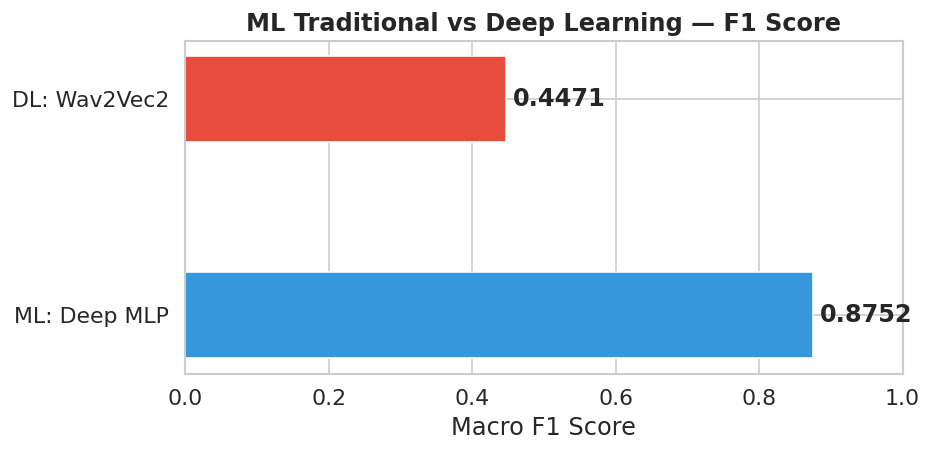


━━━ Output Files ━━━
   📄 models/best_cefr_classifier.pkl (255.6 KB)
   📄 models/cefr_deep_mlp.pkl (255.6 KB)
   📄 models/cefr_random_forest.pkl (29438.7 KB)
   📄 models/cefr_svm_rbf.pkl (564.8 KB)
   📄 models/cefr_xgboost.pkl (1357.2 KB)
   📄 models/label_encoder.pkl (0.5 KB)
   📄 models/prosody_regressor.pkl (81995.8 KB)
   📄 ./cefr-wav2vec2-final/README.md (5.0 KB)
   📄 ./cefr-wav2vec2-final/adapter_config.json (1.1 KB)
   📄 ./cefr-wav2vec2-final/adapter_model.safetensors (4627.6 KB)
   📄 ./cefr-wav2vec2-final/label_map.json (0.3 KB)
   📄 ./cefr-wav2vec2-final/preprocessor_config.json (0.2 KB)
   📄 ./cefr-wav2vec2-final/training_args.bin (5.1 KB)

✅ SEMUA PROSES SELESAI!
   Model siap untuk AI English Speaking Coach.


In [18]:
# ====================================================================
# RINGKASAN AKHIR + PERBANDINGAN
# ====================================================================

print('=' * 60)
print('🎓 FINAL SUMMARY')
print('   AI English Speaking Coach & Assessment Engine')
print('=' * 60)

# ---- Part A Summary ----
if best_ml_model is not None:
    print(f'\n━━━ Part A: ML Traditional ━━━')
    summary_a = pd.DataFrame({
        'Model': list(ml_results.keys()),
        'Accuracy': [ml_results[m]['accuracy'] for m in ml_results],
        'F1': [ml_results[m]['f1'] for m in ml_results]
    }).round(4)
    print(summary_a.to_string(index=False))
    print(f'🏆 Best: {best_ml_name} (F1={best_ml_f1:.4f})')
    if rmse is not None:
        print(f'📈 Regression: RMSE={rmse:.4f} | R²={r2:.4f}')

# ---- Part B Summary ----
if run_partB:
    print(f'\n━━━ Part B: Wav2Vec2 Deep Learning ━━━')
    print(f'   Accuracy: {eval_res["eval_accuracy"]:.4f}')
    print(f'   F1 Macro: {eval_res["eval_f1_macro"]:.4f}')

# ---- Comparison Chart ----
comparison = {}
if best_ml_model is not None:
    comparison[f'ML: {best_ml_name}'] = best_ml_f1
if run_partB:
    comparison['DL: Wav2Vec2'] = eval_res['eval_f1_macro']

if len(comparison) > 1:
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(list(comparison.keys()), list(comparison.values()),
                   color=['#3498db', '#e74c3c'], edgecolor='white', height=0.4)
    ax.set_title('ML Traditional vs Deep Learning — F1 Score', fontweight='bold')
    ax.set_xlabel('Macro F1 Score')
    ax.set_xlim(0, 1)
    for bar, v in zip(bars, comparison.values()):
        ax.text(v + 0.01, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('final_comparison.png', bbox_inches='tight', dpi=150)
    plt.show()

# ---- Output Files ----
print(f'\n━━━ Output Files ━━━')
if os.path.exists('models'):
    for f in sorted(os.listdir('models')):
        size = os.path.getsize(f'models/{f}') / 1024
        print(f'   📄 models/{f} ({size:.1f} KB)')
if run_partB and os.path.exists(SAVE_DIR):
    for f in sorted(os.listdir(SAVE_DIR)):
        size = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1024
        print(f'   📄 {SAVE_DIR}/{f} ({size:.1f} KB)')

print(f'\n✅ SEMUA PROSES SELESAI!')
print('   Model siap untuk AI English Speaking Coach.')